--- Starting Dual Language 2015 Analysis ---


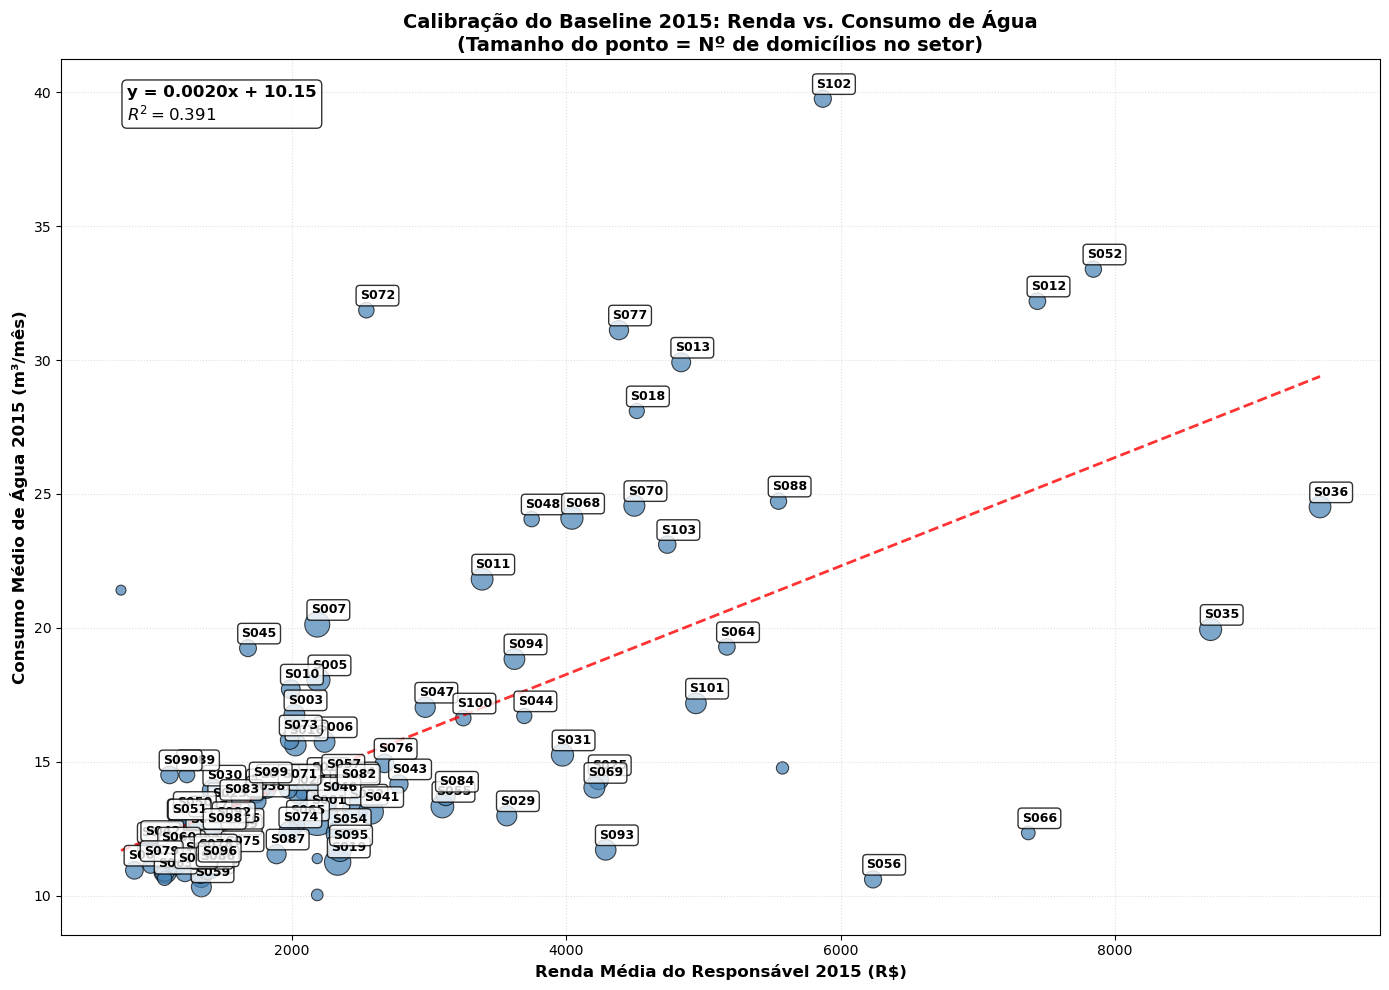

File saved: ..\figuras\grafico_ resultado_analise_consumo_x_renda_itapua_2015_pt.pdf (R²: 0.391)


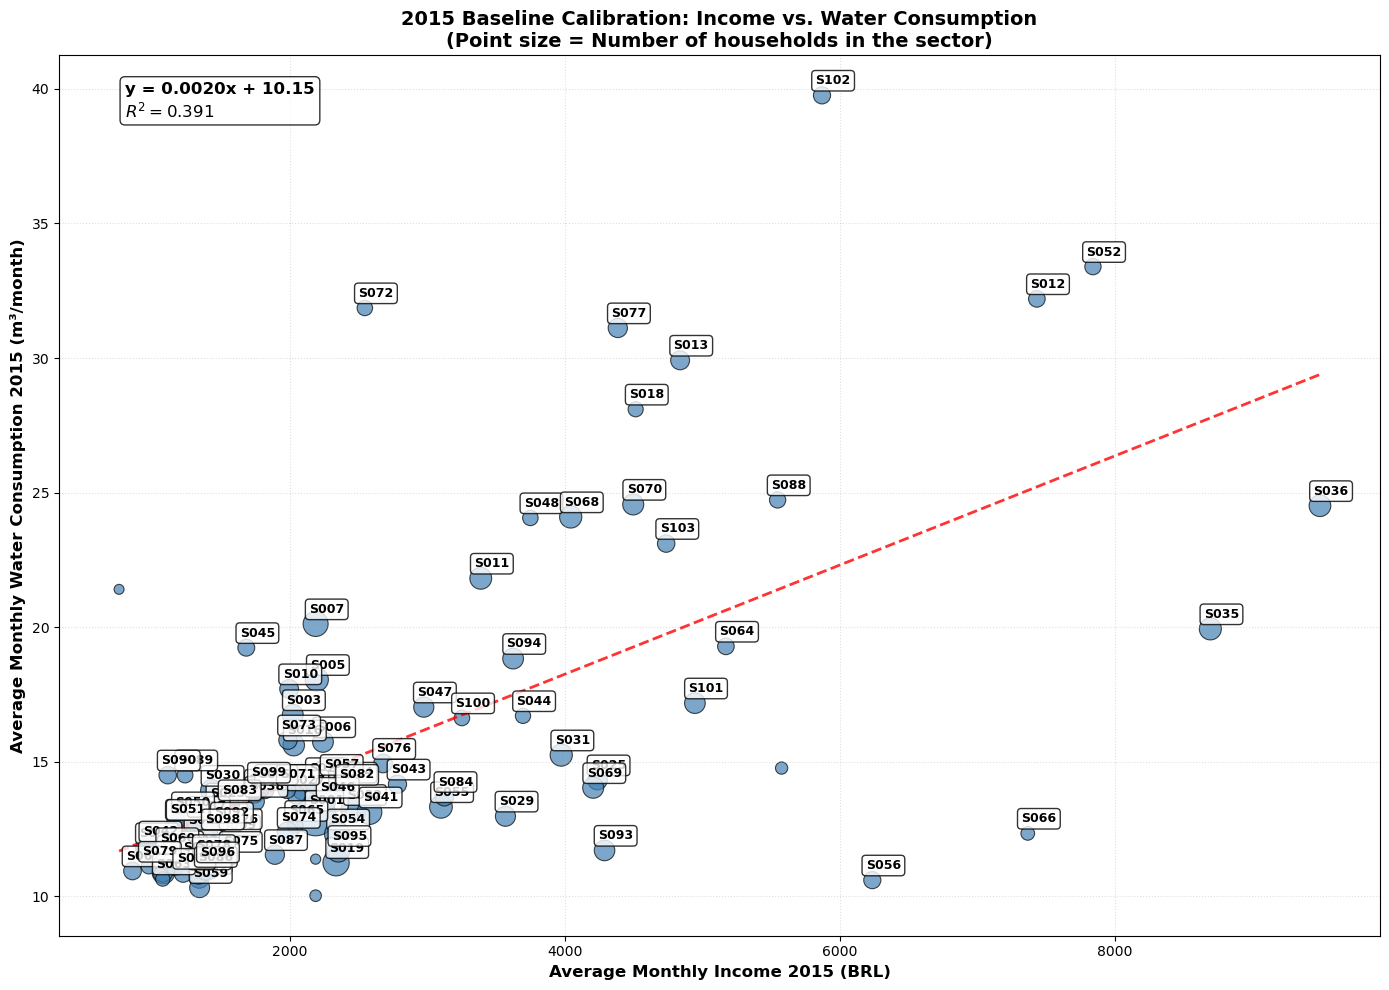

File saved: ..\figuras\grafico_ resultado_analise_consumo_x_renda_itapua_2015_en.pdf (R²: 0.391)
------------------------------
Process complete. Dual PDFs generated in 'figuras' folder.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# ==========================================
# 1. Configuration and Style
# ==========================================
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['font.family'] = 'DejaVu Sans'

BASE_PATH = '..' 

# ==========================================
# 2. Helper Functions
# ==========================================

def convert_sector_id_short(full_sector_id):
    """ Safely converts long Sector ID to short format (SXXX). """
    sector_str = str(full_sector_id).strip()
    if sector_str.lower() in ['nan', '', 'none']:
        return 'S000'
    if len(sector_str) < 15 and sector_str.replace('.0', '').isdigit():
        sector_str = sector_str.replace('.0', '').zfill(15)
    try:
        return 'S' + sector_str[7] + sector_str[-2:]
    except IndexError:
        return 'S' + sector_str[-3:] if len(sector_str) >= 3 else 'S000'

def generate_plot(df, lang='en'):
    """ Generates and saves the plot in the specified language. """
    plt.figure(figsize=(14, 10))
    
    x_data = df['VL_RENDA_2015']
    y_data = df['NN_MEDIA_CONSUMO']
    
    # Scatter plot
    plt.scatter(
        x_data, y_data,
        s=df['QTD_CONSUMIDORES'] * 0.8 + 50,
        alpha=0.7, c='steelblue', edgecolors='black', linewidth=0.8
    )
    
    # Regression
    z = np.polyfit(x_data, y_data, 1)
    p = np.poly1d(z)
    r_squared = 1 - (np.sum((y_data - p(x_data))**2) / np.sum((y_data - np.mean(y_data))**2))
    
    x_range = np.linspace(x_data.min(), x_data.max(), 100)
    plt.plot(x_range, p(x_range), "r--", alpha=0.8, linewidth=2)

    # Sector labels
    for i, row in df.iterrows():
        if row['QTD_CONSUMIDORES'] > 50:
            plt.annotate(f"{row['CD_SETOR_SXXX']}", 
                         (row['VL_RENDA_2015'], row['NN_MEDIA_CONSUMO']),
                         xytext=(8, 8), textcoords='offset points', fontsize=9, fontweight='bold',
                         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8), ha='center')

    # Language Dictionary
    content = {
        'pt': {
            'xlabel': 'Renda Média do Responsável 2015 (R$)',
            'ylabel': 'Consumo Médio de Água 2015 (m³/mês)',
            'title': 'Calibração do Baseline 2015: Renda vs. Consumo de Água\n(Tamanho do ponto = Nº de domicílios no setor)',
            'legend': 'Linha de Tendência',
            'filename': 'grafico_ resultado_analise_consumo_x_renda_itapua_2015_pt.pdf'
        },
        'en': {
            'xlabel': 'Average Monthly Income 2015 (BRL)',
            'ylabel': 'Average Monthly Water Consumption 2015 (m³/month)',
            'title': '2015 Baseline Calibration: Income vs. Water Consumption\n(Point size = Number of households in the sector)',
            'legend': 'Trend Line',
            'filename': 'grafico_ resultado_analise_consumo_x_renda_itapua_2015_en.pdf'
        }
    }
    
    c = content[lang]
    plt.xlabel(c['xlabel'], fontsize=12, fontweight='bold')
    plt.ylabel(c['ylabel'], fontsize=12, fontweight='bold')
    plt.title(c['title'], fontsize=14, fontweight='bold')
    
    stats_text = f"y = {z[0]:.4f}x + {z[1]:.2f}\n$R^2 = {r_squared:.3f}$"
    plt.text(0.05, 0.93, stats_text, transform=plt.gca().transAxes, fontsize=12, 
             fontweight='bold', bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

    plt.grid(True, linestyle=':', alpha=0.4)
    plt.tight_layout()
    plt.show()
    fig_dir = os.path.join(BASE_PATH, 'figuras')
    os.makedirs(fig_dir, exist_ok=True)
    save_path = os.path.join(fig_dir, c['filename'])
    plt.savefig(save_path, format='pdf', dpi=300, bbox_inches='tight')
    print(f"File saved: {save_path} (R²: {r_squared:.3f})")
    plt.close()

def main():
    print("--- Starting Dual Language 2015 Analysis ---")
    
    master_path = os.path.join(BASE_PATH, 'includes', 'Tabela_consumidores_Itapua_com_setor_comportamento_e_renda_2015.csv')
    df = pd.read_csv(master_path, sep=';')
    df['CD_SETOR'] = df['CD_SETOR'].astype(str)

    sector_analysis = df.groupby('CD_SETOR').agg({
        'NN_MEDIA_CONSUMO': 'mean',
        'VL_RENDA_2015': 'mean',
        'SK_MATRICULA': 'count'
    }).reset_index()

    sector_analysis.rename(columns={'SK_MATRICULA': 'QTD_CONSUMIDORES'}, inplace=True)
    sector_analysis['CD_SETOR_SXXX'] = sector_analysis['CD_SETOR'].apply(convert_sector_id_short)

    # Filtering valid data
    sector_analysis = sector_analysis[(sector_analysis['NN_MEDIA_CONSUMO'] > 0) & 
                                      (sector_analysis['NN_MEDIA_CONSUMO'] < 50) &
                                      (sector_analysis['VL_RENDA_2015'] > 0)]

    # Generate both outputs
    generate_plot(sector_analysis, lang='pt')
    generate_plot(sector_analysis, lang='en')
    
    print("-" * 30)
    print("Process complete. Dual PDFs generated in 'figuras' folder.")

if __name__ == "__main__":
    main()